In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_12_png.rf.566726d03bb59741293c5a5c58d71f5e_aug_2.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_45_png.rf.7b0c39c7948b368961c4bbc376c93d99.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_43_png.rf.225187fb6b8111d171ffcccb2e905e3a_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_50_png.rf.15b257af83325aa3721cf4463a3ce1b8_aug_1.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_47_png.rf.96ba9988494f51b9f661609792706976_aug_0.jpg
/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/Augumented/Augumented/augmented_stage2/train/LER/image_24_png.rf.8e55a751c663f1c4fb91639

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import shufflenet_v2_x1_0, ShuffleNet_V2_X1_0_Weights
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import copy

# -----------------------
# Device
# -----------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------
# Data Transforms
# -----------------------

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05),
        scale=(0.9,1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------
# Load Dataset
# -----------------------

train_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/stage2/train",
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/stage2/valid",
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/prasadmalaiiiitk/sem-data03/sem-dataset/stage2/test",
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

num_classes = len(train_dataset.classes)

# -----------------------
# Class Weights
# -----------------------

class_counts = np.bincount(train_dataset.targets, minlength=num_classes)
total_samples = sum(class_counts)

class_weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# -----------------------
# Load Pretrained ShuffleNet
# -----------------------

weights = ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
model = shufflenet_v2_x1_0(weights=weights)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# -----------------------
# Stage 1: Freeze Backbone
# -----------------------

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0
patience = 7
trigger_times = 0

# -----------------------
# Training Function
# -----------------------

def train_model(num_epochs):
    global best_acc, best_model_wts, trigger_times

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ---- Training ----
        model.train()
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

        train_acc = correct / total
        print("Train Accuracy:", train_acc)

        # ---- Validation ----
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = outputs.max(1)
                total += labels.size(0)
                correct += preds.eq(labels).sum().item()

        val_acc = correct / total
        print("Validation Accuracy:", val_acc)

        scheduler.step(val_acc)

        # Early stopping
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print("Early stopping triggered")
                break

# -----------------------
# Stage 1
# -----------------------
print("\nStage 1: Training classifier only")
train_model(10)

# -----------------------
# Stage 2: Fine-tuning
# -----------------------
print("\nStage 2: Fine-tuning full network")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3
)

train_model(25)

# -----------------------
# Load Best Model
# -----------------------
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_shufflenet_model.pth")

print("Best Validation Accuracy:", best_acc)

# -----------------------
# Test Evaluation
# -----------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\nTest Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Using device: cpu
Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 152MB/s]



Stage 1: Training classifier only

Epoch 1/10
Train Accuracy: 0.5088757396449705
Validation Accuracy: 0.47540983606557374

Epoch 2/10
Train Accuracy: 0.7712031558185405
Validation Accuracy: 0.6065573770491803

Epoch 3/10
Train Accuracy: 0.7919132149901381
Validation Accuracy: 0.6065573770491803

Epoch 4/10
Train Accuracy: 0.8175542406311637
Validation Accuracy: 0.639344262295082

Epoch 5/10
Train Accuracy: 0.8165680473372781
Validation Accuracy: 0.6721311475409836

Epoch 6/10
Train Accuracy: 0.8293885601577909
Validation Accuracy: 0.6557377049180327

Epoch 7/10
Train Accuracy: 0.8185404339250493
Validation Accuracy: 0.6885245901639344

Epoch 8/10
Train Accuracy: 0.8096646942800789
Validation Accuracy: 0.7049180327868853

Epoch 9/10
Train Accuracy: 0.8185404339250493
Validation Accuracy: 0.7213114754098361

Epoch 10/10
Train Accuracy: 0.8323471400394478
Validation Accuracy: 0.7049180327868853

Stage 2: Fine-tuning full network

Epoch 1/25
Train Accuracy: 0.8451676528599605
Validation A

In [5]:
!pip install -U onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.4 MB/s eta 0:00:00


In [6]:
import onnxscript
import torch

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "shufflenet_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print("ONNX model saved successfully!")

/tmp/ipykernel_55/3120312940.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0301 08:33:01.896000 55 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0301 08:33:03.057000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned:

[torch.onnx] Obtain model graph for `ShuffleNetV2([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ShuffleNetV2([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Runtim

Applied 120 of general pattern rewrite rules.
ONNX model saved successfully!


In [7]:
traced_model = torch.jit.trace(model, dummy_input)
traced_model.save("shufflenet_model.pt")

print("TorchScript model saved!")

TorchScript model saved!


In [10]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

accuracy = accuracy_score(all_labels, all_preds)

report = classification_report(all_labels, all_preds, output_dict=True)

num_classes = len(train_dataset.classes)
f1_scores = [report[str(i)]['f1-score'] for i in range(num_classes)]

print("Test Accuracy:", accuracy)
print("F1 per class:", f1_scores)

Test Accuracy: 0.7941176470588235
F1 per class: [0.88, 0.8461538461538461, 0.9090909090909091, 0.7567567567567568, 0.6153846153846154]


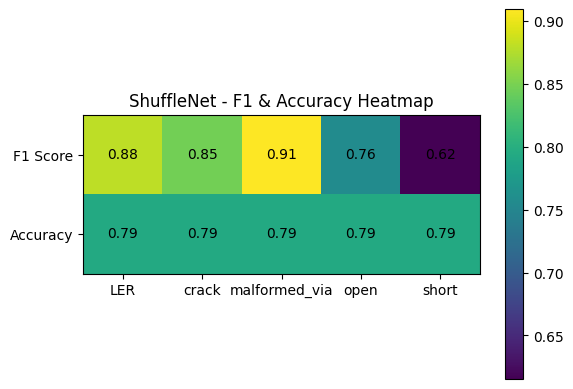

In [11]:
import matplotlib.pyplot as plt

heatmap_data = np.array([
    f1_scores,
    [accuracy] * num_classes
])

plt.figure()
plt.imshow(heatmap_data)

plt.xticks(range(num_classes), train_dataset.classes)
plt.yticks([0, 1], ["F1 Score", "Accuracy"])

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        plt.text(j, i, round(heatmap_data[i, j], 2),
                 ha="center", va="center")

plt.title("ShuffleNet - F1 & Accuracy Heatmap")
plt.colorbar()
plt.show()